In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

Load Bank Personal Loan Modelling dataset

In [2]:
cost_matrix = np.array([[0, 5], [1, 0]])
print('Nếu tín dụng xấu được phân là xấu, chi phí:', cost_matrix[0][0])
print('Nếu tín dụng xấu được phân là tốt, chi phí:', cost_matrix[0][1])
print('Nếu tín dụng tốt được phân là xấu, chi phí:', cost_matrix[1][0])
print('Nếu tín dụng tốt được phân là tốt, chi phí:', cost_matrix[1][1])
# kiểu thà giết nhầm còn hơn bỏ sót

Nếu tín dụng xấu được phân là xấu, chi phí: 0
Nếu tín dụng xấu được phân là tốt, chi phí: 5
Nếu tín dụng tốt được phân là xấu, chi phí: 1
Nếu tín dụng tốt được phân là tốt, chi phí: 0


In [3]:
# file german.data-numeric có dạng ma trận mỗi số cách nhau bởi dấu cách, có 25 cột
# sử dụng genfromtxt của np để tạo array (tự động xác định các khoảng trắng)
base_dir = os.getcwd()
data_dir = os.path.join(base_dir, 'Ex4', 'Practice', 'german.data-numeric')
data_array = np.genfromtxt(data_dir)

In [4]:
feature = [f"A{i}" for i in range(1,25)]
feature.append('label')
df = pd.DataFrame(data = data_array, columns = feature)

In [5]:
df

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,...,A16,A17,A18,A19,A20,A21,A22,A23,A24,label
0,1.0,6.0,4.0,12.0,5.0,5.0,3.0,4.0,1.0,67.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0
1,2.0,48.0,2.0,60.0,1.0,3.0,2.0,2.0,1.0,22.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,2.0
2,4.0,12.0,4.0,21.0,1.0,4.0,3.0,3.0,1.0,49.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
3,1.0,42.0,2.0,79.0,1.0,4.0,3.0,4.0,2.0,45.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
4,1.0,24.0,3.0,49.0,1.0,3.0,3.0,4.0,4.0,53.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,4.0,12.0,2.0,17.0,1.0,4.0,2.0,4.0,1.0,31.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
996,1.0,30.0,2.0,39.0,1.0,3.0,1.0,4.0,2.0,40.0,...,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
997,4.0,12.0,2.0,8.0,1.0,5.0,3.0,4.0,3.0,38.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0
998,1.0,45.0,2.0,18.0,1.0,3.0,3.0,4.0,4.0,23.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0


In [6]:
# label 1 là good, 2 là bad, chuyển bad về 0
df['label'] = df['label'].replace(2,0)

In [7]:
df.head()

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,...,A16,A17,A18,A19,A20,A21,A22,A23,A24,label
0,1.0,6.0,4.0,12.0,5.0,5.0,3.0,4.0,1.0,67.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0
1,2.0,48.0,2.0,60.0,1.0,3.0,2.0,2.0,1.0,22.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
2,4.0,12.0,4.0,21.0,1.0,4.0,3.0,3.0,1.0,49.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
3,1.0,42.0,2.0,79.0,1.0,4.0,3.0,4.0,2.0,45.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
4,1.0,24.0,3.0,49.0,1.0,3.0,3.0,4.0,4.0,53.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 25 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   A1      1000 non-null   float64
 1   A2      1000 non-null   float64
 2   A3      1000 non-null   float64
 3   A4      1000 non-null   float64
 4   A5      1000 non-null   float64
 5   A6      1000 non-null   float64
 6   A7      1000 non-null   float64
 7   A8      1000 non-null   float64
 8   A9      1000 non-null   float64
 9   A10     1000 non-null   float64
 10  A11     1000 non-null   float64
 11  A12     1000 non-null   float64
 12  A13     1000 non-null   float64
 13  A14     1000 non-null   float64
 14  A15     1000 non-null   float64
 15  A16     1000 non-null   float64
 16  A17     1000 non-null   float64
 17  A18     1000 non-null   float64
 18  A19     1000 non-null   float64
 19  A20     1000 non-null   float64
 20  A21     1000 non-null   float64
 21  A22     1000 non-null   float64
 22  A23     1000

In [9]:
df.describe()

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,...,A16,A17,A18,A19,A20,A21,A22,A23,A24,label
count,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,...,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.0000,1000.000000,1000.000000
mean,2.577000,20.903000,2.54500,32.711000,2.105000,3.384000,2.68200,2.845000,2.358000,35.546000,...,0.234000,0.103000,0.907000,0.041000,0.179000,0.713000,0.022000,0.2000,0.630000,0.700000
std,1.257638,12.058814,1.08312,28.252605,1.580023,1.208306,0.70808,1.103718,1.050209,11.375469,...,0.423584,0.304111,0.290578,0.198389,0.383544,0.452588,0.146757,0.4002,0.483046,0.458487
min,1.000000,4.000000,0.00000,2.000000,1.000000,1.000000,1.00000,1.000000,1.000000,19.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,0.000000
25%,1.000000,12.000000,2.00000,14.000000,1.000000,3.000000,2.00000,2.000000,1.000000,27.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,0.000000
50%,2.000000,18.000000,2.00000,23.000000,1.000000,3.000000,3.00000,3.000000,2.000000,33.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.0000,1.000000,1.000000
75%,4.000000,24.000000,4.00000,40.000000,3.000000,5.000000,3.00000,4.000000,3.000000,42.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.0000,1.000000,1.000000
max,4.000000,72.000000,4.00000,184.000000,5.000000,5.000000,4.00000,4.000000,4.000000,75.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.0000,1.000000,1.000000


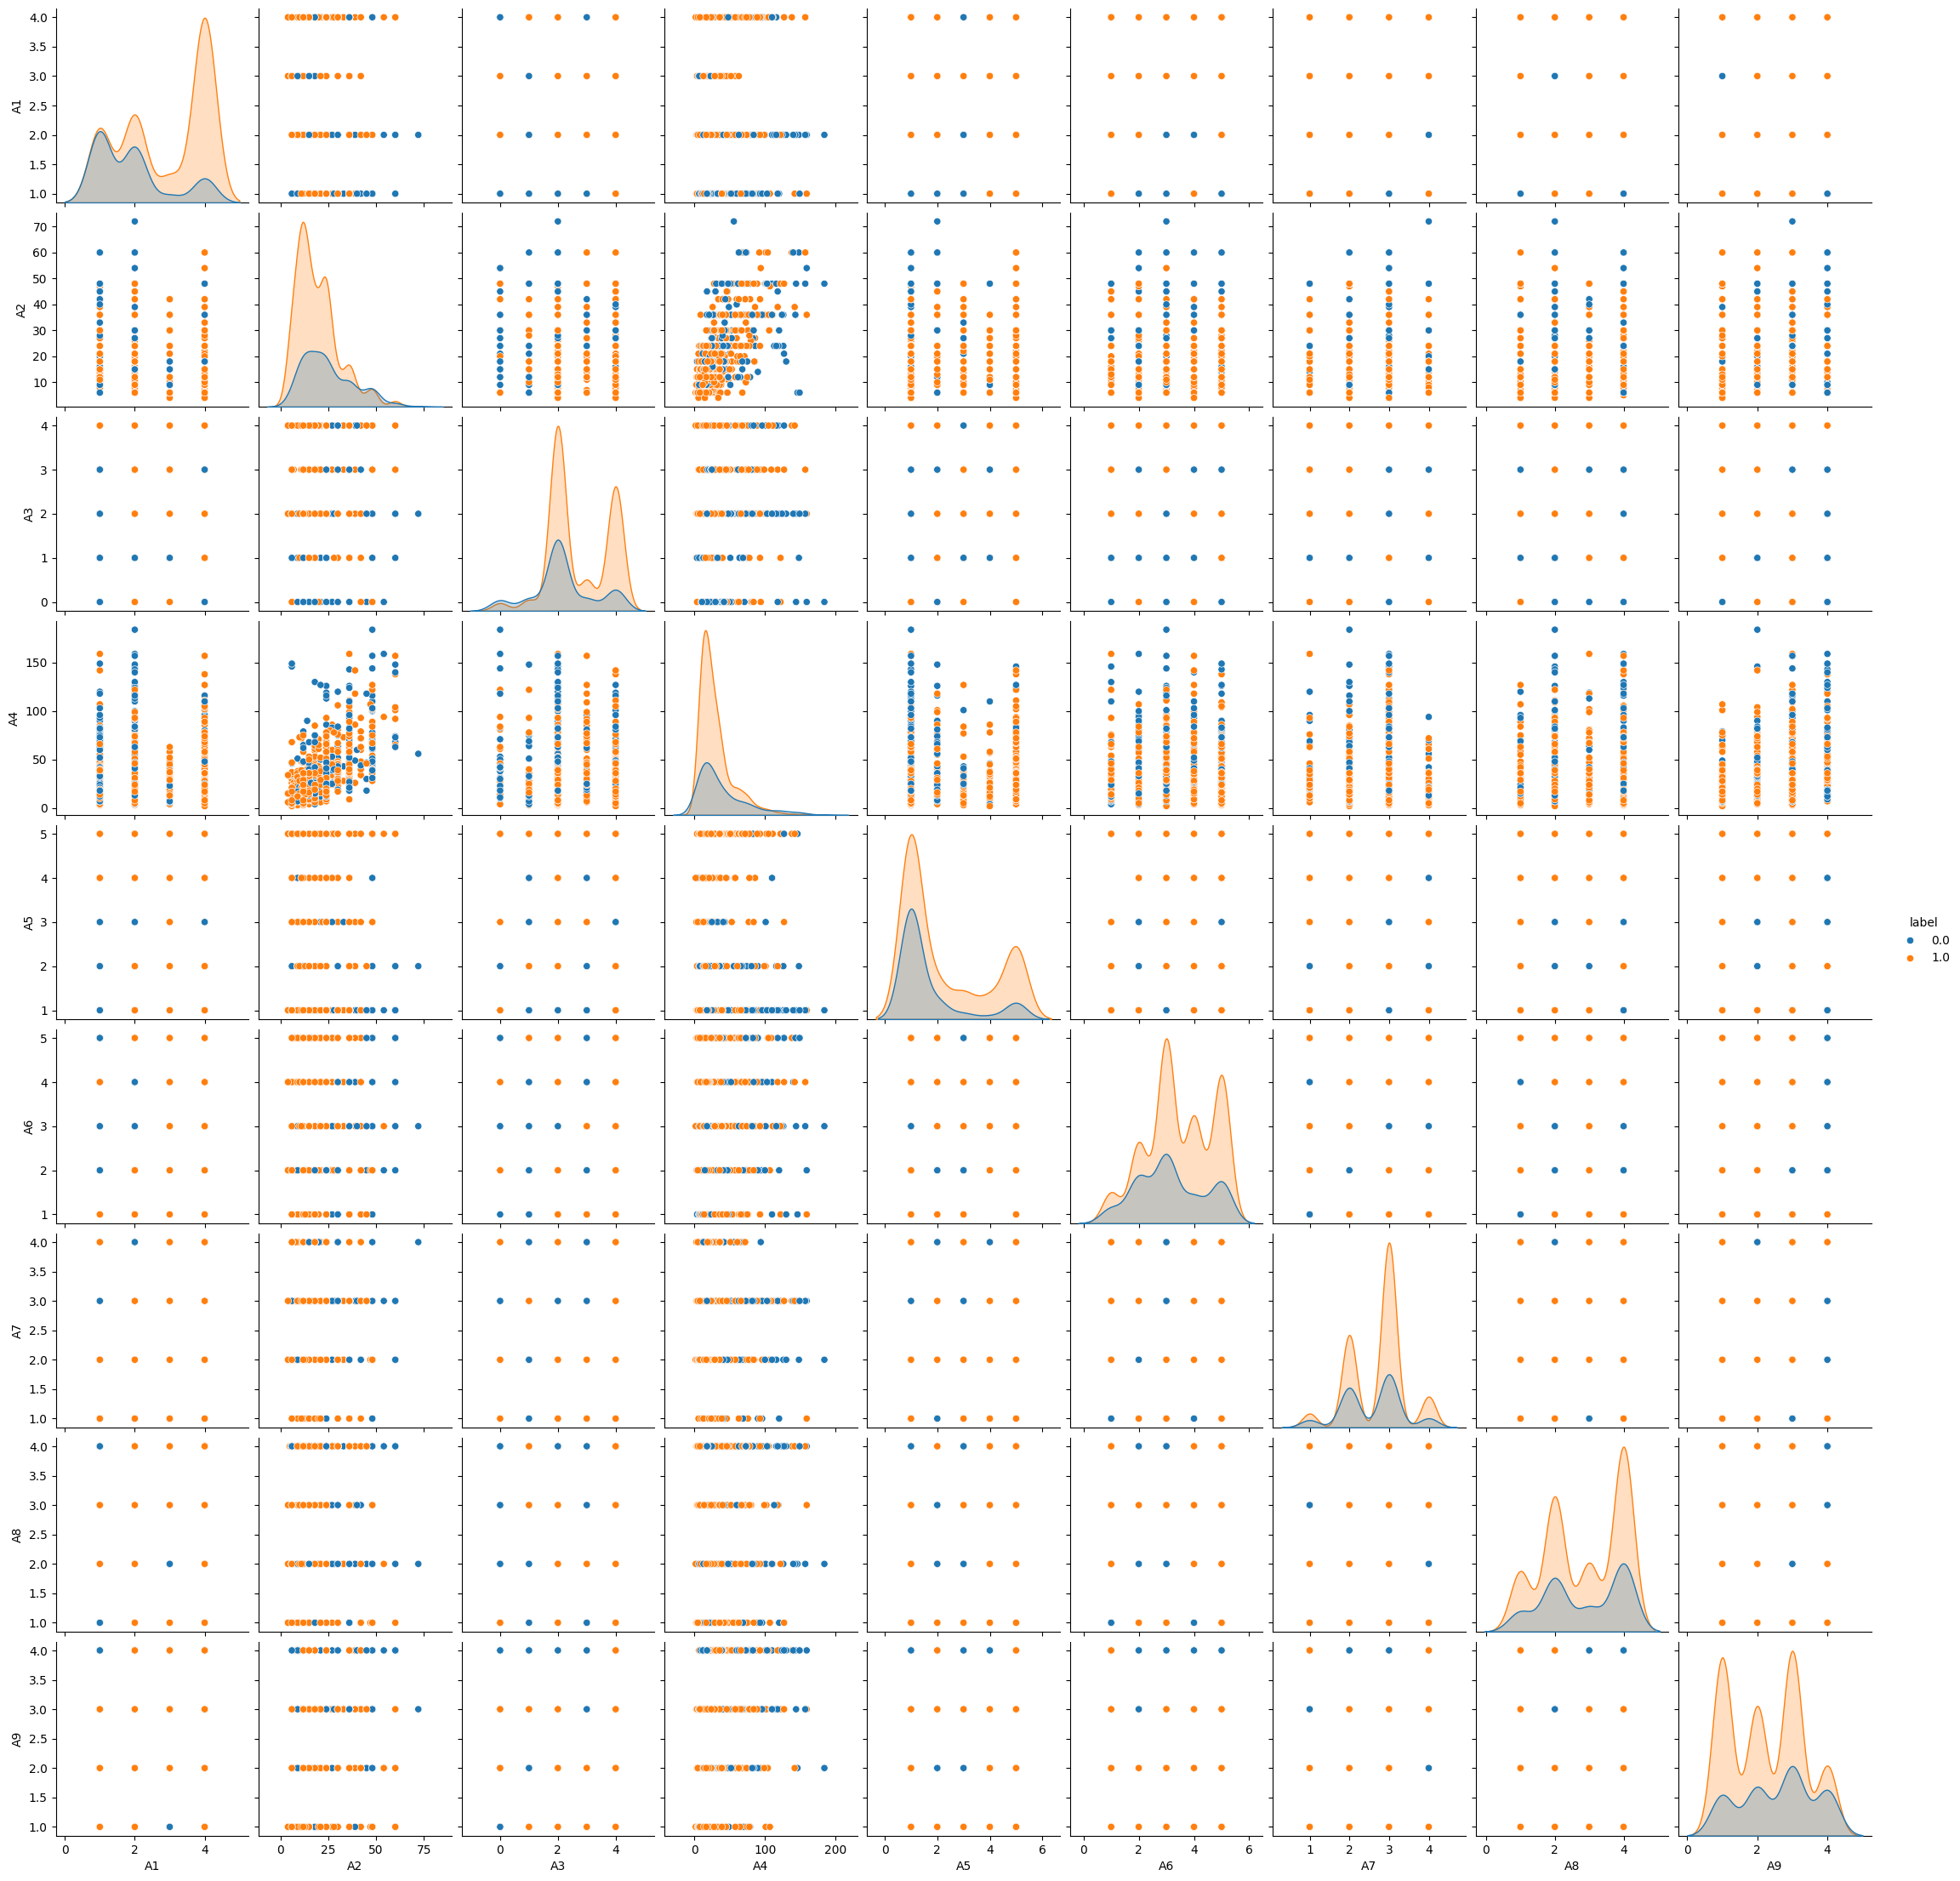

In [10]:
sns.pairplot(df,
             hue = 'label',
             vars = [f"A{i}" for i in range(1,10)])

In [11]:
df['label'].value_counts()

label
1.0    700
0.0    300
Name: count, dtype: int64

<Axes: >

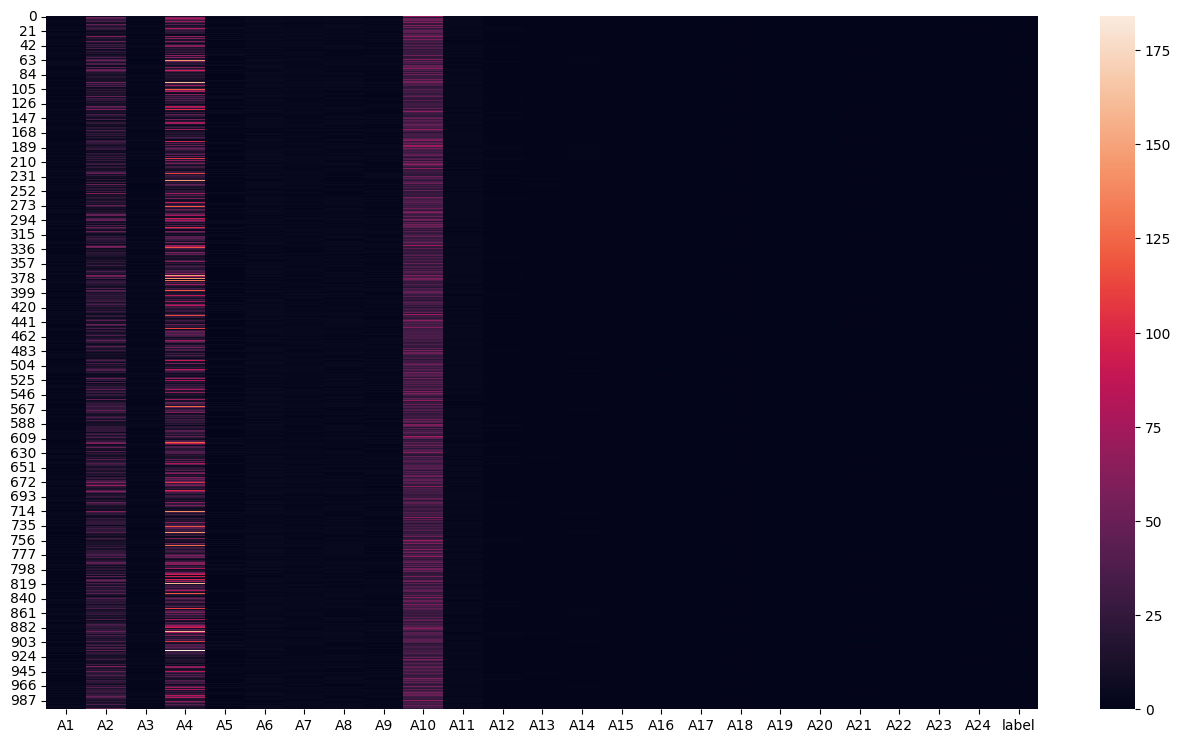

In [12]:
plt.figure(figsize = (16,9))
sns.heatmap(df)

Có thể thấy các feature có các thang đo giá trị khác nhau có các feature chỉ toàn có giá trị bé có các feature có giá trị rất lớn

<Axes: >

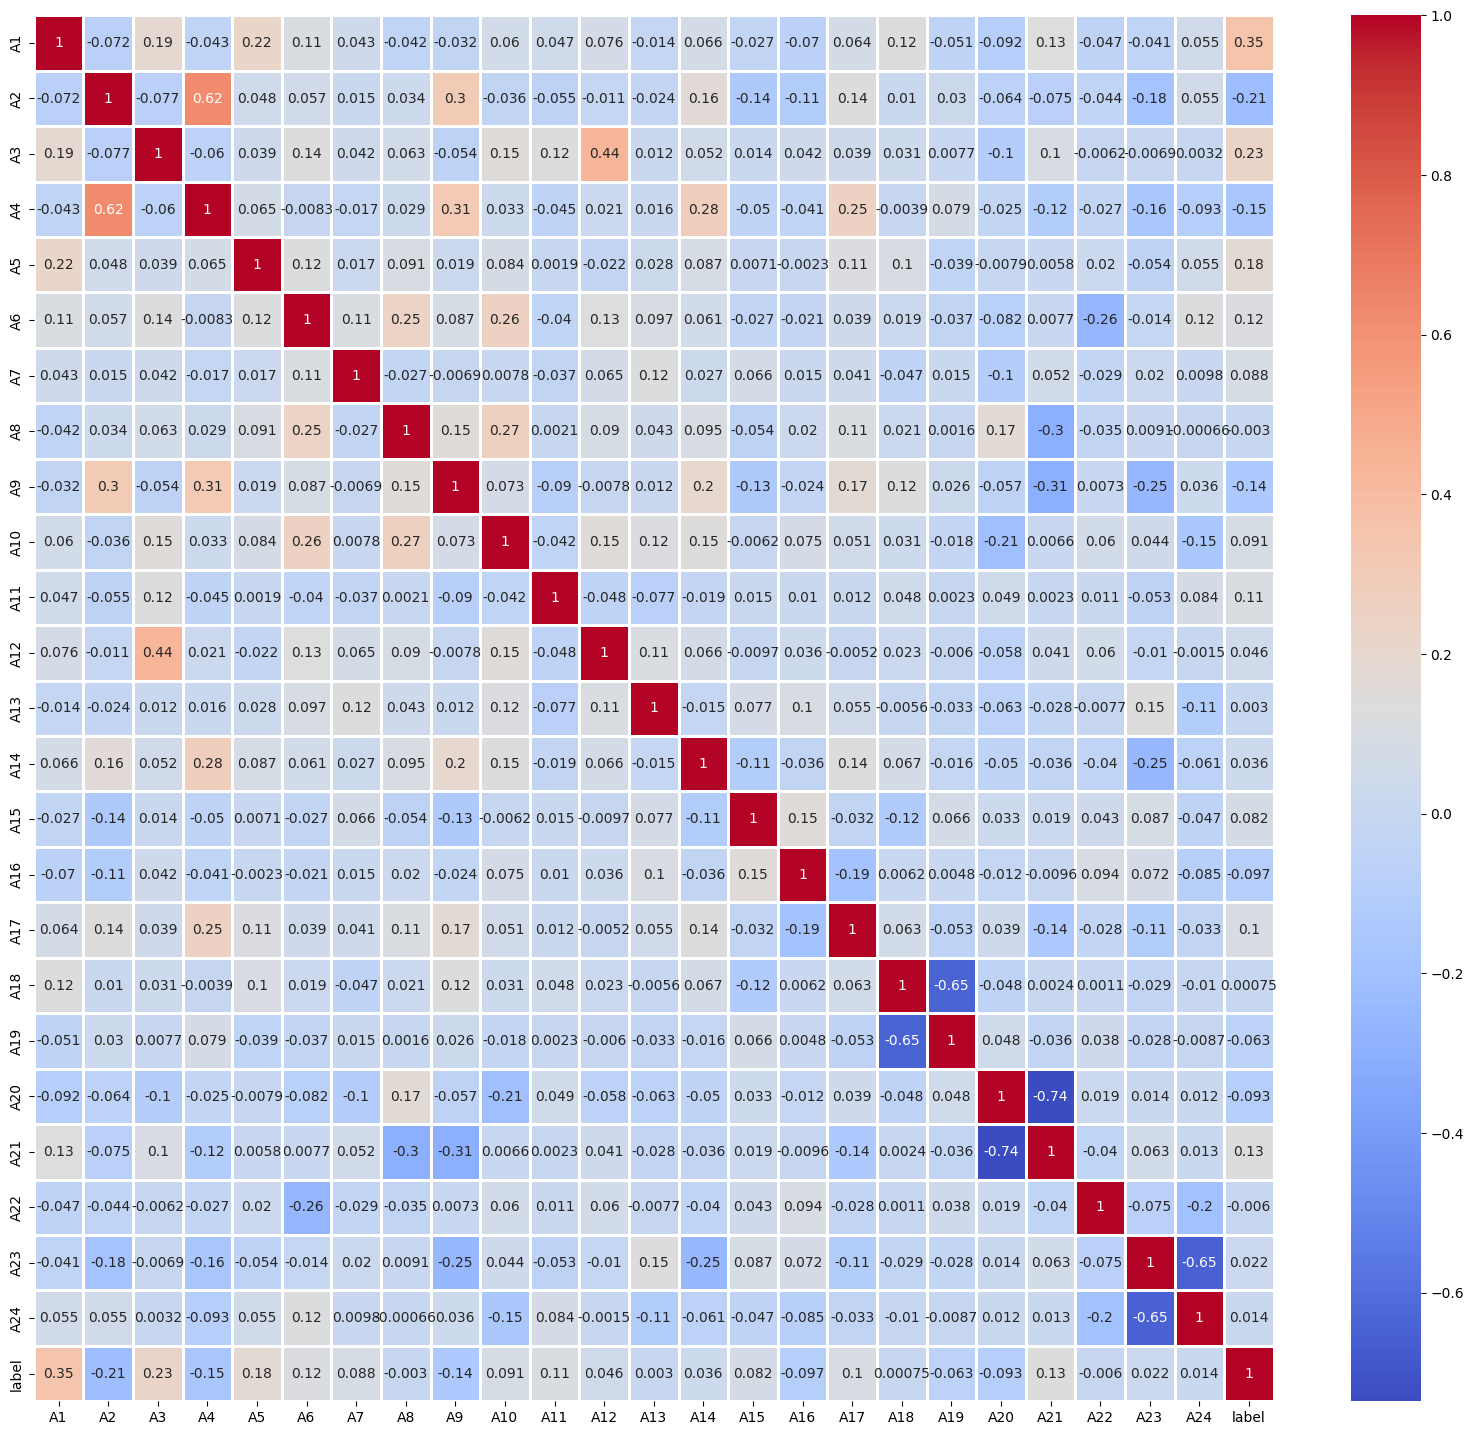

In [13]:
plt.figure(figsize = (20,18))
sns.heatmap(df.corr(), cmap = 'coolwarm', annot = True, linewidth = 2)

Chú ý để ý xem có 2 biến nào tương quan cao không ( trừ nhãn ra ), và tiếp tục xem có biến nào tương quan thấp với label không, có thể xem xét loại bỏ các feature có biến ít tương quan với label (độ tương quan lấy giá trị tuyệt đối, độ tương quan thấp là các giá trị gần 0)

In [14]:
from sklearn.model_selection import train_test_split
X = df.drop(columns = ['label'])
y = df['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 36)
X_train.shape, X_test.shape

((800, 24), (200, 24))

In [15]:
# vì các feature đang có thang đo khác nhau nên cần chuẩn hóa, có thể chuẩn hóa sử dụng standard scaler
# chú ý là scale sau khi đã chia tập train test chứ không scale trước rồi chia sau
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
sc.fit(X_train)
X_train = sc.transform(X_train)
X_test = sc.transform(X_test)

In [16]:
pd.DataFrame(X_train).describe()

,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
count,8.000000e+02,8.000000e+02,8.000000e+02,8.000000e+02,8.000000e+02,8.000000e+02,8.000000e+02,8.000000e+02,8.000000e+02,8.000000e+02,...,8.000000e+02,8.000000e+02,8.000000e+02,8.000000e+02,8.000000e+02,8.000000e+02,8.000000e+02,8.000000e+02,8.000000e+02,8.000000e+02
mean,6.661338e-17,2.664535e-17,1.687539e-16,1.243450e-16,2.886580e-17,-1.443290e-17,2.065015e-16,1.310063e-16,-1.776357e-17,-2.842171e-16,...,4.063416e-16,4.385381e-17,3.552714e-17,2.153833e-16,-8.770762e-17,5.329071e-17,8.881784e-17,8.881784e-18,8.881784e-17,-5.329071e-17
std,1.000626e+00,1.000626e+00,1.000626e+00,1.000626e+00,1.000626e+00,1.000626e+00,1.000626e+00,1.000626e+00,1.000626e+00,1.000626e+00,...,1.000626e+00,1.000626e+00,1.000626e+00,1.000626e+00,1.000626e+00,1.000626e+00,1.000626e+00,1.000626e+00,1.000626e+00,1.000626e+00
min,-1.260849e+00,-1.416399e+00,-2.362502e+00,-1.091780e+00,-6.979531e-01,-1.958646e+00,-2.315680e+00,-1.694167e+00,-1.323036e+00,-1.444406e+00,...,-1.904453e-01,-5.542468e-01,-3.560345e-01,-3.155773e+00,-2.041241e-01,-4.724845e-01,-1.527525e+00,-1.601282e-01,-4.744627e-01,-1.329724e+00
25%,-1.260849e+00,-7.495639e-01,-5.077409e-01,-6.755994e-01,-6.979531e-01,-3.014098e-01,-9.143609e-01,-7.845469e-01,-1.323036e+00,-7.582275e-01,...,-1.904453e-01,-5.542468e-01,-3.560345e-01,3.168796e-01,-2.041241e-01,-4.724845e-01,-1.527525e+00,-1.601282e-01,-4.744627e-01,-1.329724e+00
50%,-4.653605e-01,-2.494378e-01,-5.077409e-01,-3.287825e-01,-6.979531e-01,-3.014098e-01,4.869585e-01,1.250727e-01,5.619661e-01,-2.435935e-01,...,-1.904453e-01,-5.542468e-01,-3.560345e-01,3.168796e-01,-2.041241e-01,-4.724845e-01,6.546537e-01,-1.601282e-01,-4.744627e-01,7.520357e-01
75%,1.125616e+00,2.506882e-01,1.347020e+00,2.608063e-01,5.753935e-01,5.272081e-01,4.869585e-01,1.034692e+00,5.619661e-01,5.283577e-01,...,-1.904453e-01,-5.542468e-01,-3.560345e-01,3.168796e-01,-2.041241e-01,-4.724845e-01,6.546537e-01,-1.601282e-01,-4.744627e-01,7.520357e-01
max,1.125616e+00,3.251444e+00,1.347020e+00,4.353246e+00,1.848740e+00,1.355826e+00,1.888278e+00,1.034692e+00,1.504467e+00,3.358845e+00,...,5.250850e+00,1.804250e+00,2.808717e+00,3.168796e-01,4.898979e+00,2.116472e+00,6.546537e-01,6.244998e+00,2.107647e+00,7.520357e-01


<Axes: >

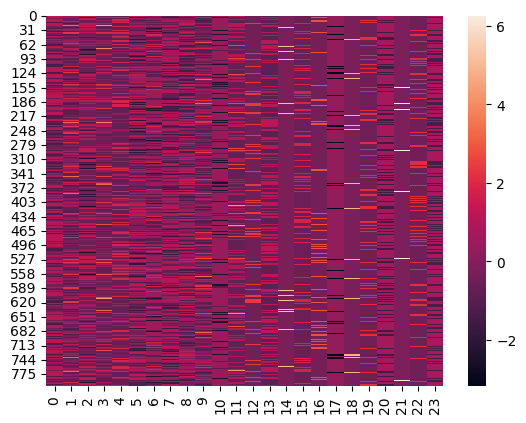

In [17]:
sns.heatmap(X_train)

<Axes: >

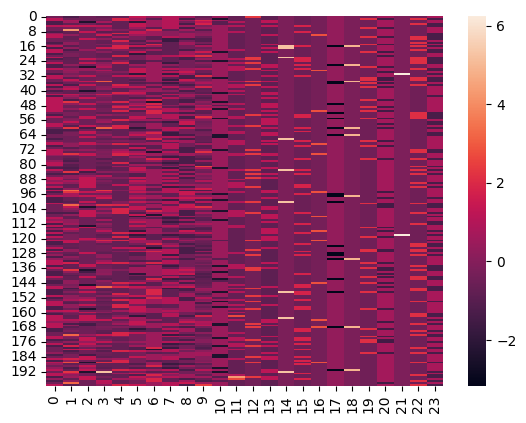

In [18]:
sns.heatmap(X_test)

In [19]:
y_train = y_train.values

In [20]:
y_test = y_test.values

In [21]:
y_test

array([1., 1., 1., 0., 0., 1., 1., 0., 0., 1., 1., 0., 1., 1., 0., 0., 1.,
       1., 1., 1., 0., 1., 1., 1., 0., 1., 0., 0., 0., 1., 1., 0., 1., 0.,
       0., 0., 1., 1., 1., 0., 0., 0., 1., 1., 1., 1., 0., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 1., 1., 1., 1., 1., 0.,
       1., 1., 0., 1., 0., 1., 1., 1., 1., 1., 1., 1., 0., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 1., 0., 1., 1., 1.,
       1., 0., 1., 1., 1., 0., 1., 1., 1., 1., 0., 1., 1., 1., 1., 1., 0.,
       1., 1., 1., 0., 1., 1., 1., 0., 1., 1., 1., 1., 0., 0., 1., 1., 1.,
       1., 0., 0., 1., 1., 1., 1., 1., 1., 0., 0., 1., 1., 0., 0., 1., 0.,
       1., 0., 1., 1., 0., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       0., 1., 1., 1., 0., 1., 1., 1., 0., 1., 0., 1., 1., 0., 0., 1., 0.,
       1., 1., 0., 1., 1., 0., 1., 1., 1., 0., 1., 0., 1.])

In [22]:
from sklearn.metrics import precision_score, recall_score, accuracy_score
from sklearn.neighbors import KNeighborsClassifier
def cost(y_true, y_pred):
    tp = ((y_true==y_pred)&(y_true==1.0))*0.0
    tn = ((y_true==y_pred)&(y_true==0.0))*0.0
    fn = ((y_true!=y_pred)&(y_true==1.0))*1.0
    fp = ((y_true!=y_pred)&(y_true==0.0))*5.0
    return sum(tp+tn+fn+fp)/len(y_true)
# trung bình cost

In [23]:
knn = KNeighborsClassifier(n_neighbors = 10, metric = 'minkowski', p =2, weights = 'distance')
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

In [24]:
print(f"Accuracy_score: {accuracy_score(y_test, y_pred_knn)}")
print(f"Cost: {cost(y_test, y_pred_knn)}")

Accuracy_score: 0.775
Cost: 0.965


In [25]:
# thay đổi số lượng láng giềng 
neighbors = [i for i in range(1,51)]
acc_score = []
cost_val = []
for i in neighbors:
    model = KNeighborsClassifier(n_neighbors = i, metric = 'minkowski', p =2, weights = 'distance')
    model.fit(X_train, y_train)
    acc_score.append(accuracy_score(y_test, model.predict(X_test)))
    cost_val.append(cost(y_test, model.predict(X_test)))

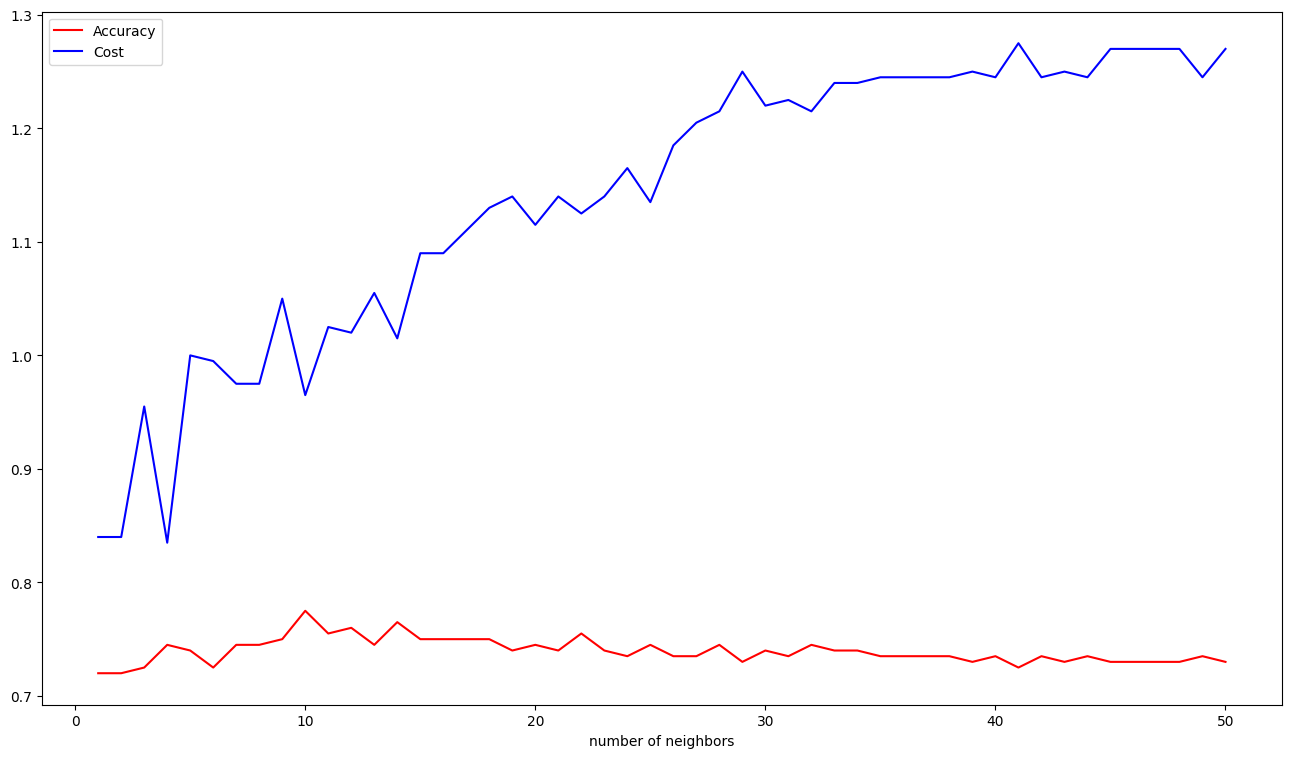

In [26]:
plt.figure(figsize = (16,9))
plt.xlabel('number of neighbors')
plt.plot(neighbors, acc_score, color = 'r', label = 'Accuracy')
plt.plot(neighbors, cost_val, color = 'b', label = 'Cost')
plt.legend()

Có thể chọn số neighbors để độ acc vừa đủ và cost không quá cao có thể chọn trong khoảng 5 đến 10, từ 1 đến 5 mặc dù có thống số hợp lí nhưng khả năng cao là overfit vì có nhiễu

In [27]:
from sklearn.linear_model import LogisticRegression
lg = LogisticRegression(penalty = 'l1', solver = 'liblinear', C = 0.1)
lg.fit(X_train, y_train)
lg.coef_[0]

c:\Weekly_Hw_GR1\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Weekly_Hw_GR1\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


array([ 0.64771837, -0.31657506,  0.29243744, -0.10404124,  0.22603421,
        0.12856167,  0.06994704,  0.        , -0.09898801,  0.04585478,
        0.04964688,  0.        ,  0.        ,  0.00846073,  0.16296005,
       -0.1339665 ,  0.19435216, -0.05836694, -0.04801569, -0.04575546,
        0.09227846,  0.03039312,  0.        ,  0.        ])

In [28]:
df_train = df.drop(columns = ['label'])
remove_candidate_lg = df_train.columns[lg.coef_[0]==0]
remove_candidate_lg

Index(['A8', 'A12', 'A13', 'A23', 'A24'], dtype='str')

Nhìn vào biểu đồ tương quan phía trên ta có thể chọn ra các feature tương quan thấp với label bao gồm:
* A8
* A13
* A18
* A22

In [53]:
remove_candidate_observe = [ 'A18','A20','A24']
# A18 có tương quan khá thấp với lable
# a20 và a21 tương quan cao với nhau có thể chọn bỏ đi 1 cái bỏ a20 vì a21 có tương quan với label cao hơn
# tương tự với a24 và a23, bỏ a24 vì a23 có tương quan với label cao hơn

In [30]:
# bỏ đi các cột theo logistic regression

X_train, X_test, y_train, y_test = train_test_split(df.drop(columns = ['label']), df['label'], test_size = 0.2, random_state = 36)

X_train_lg = X_train.drop(columns = remove_candidate_lg)
X_test_lg = X_test.drop(columns = remove_candidate_lg)
sc.fit(X_train_lg)
sc.transform(X_test_lg)
sc.transform(X_train_lg)


array([[ 1.12561560e+00,  6.25157517e-04,  4.19639708e-01, ...,
        -4.72484487e-01,  6.54653671e-01, -1.60128154e-01],
       [ 1.12561560e+00,  5.84105506e-01,  1.34702028e+00, ...,
        -4.72484487e-01,  6.54653671e-01, -1.60128154e-01],
       [ 1.12561560e+00, -4.99500856e-01, -5.07740863e-01, ...,
        -4.72484487e-01,  6.54653671e-01, -1.60128154e-01],
       ...,
       [-1.26084857e+00, -2.49437849e-01,  1.34702028e+00, ...,
         2.11647161e+00, -1.52752523e+00, -1.60128154e-01],
       [-1.26084857e+00, -7.49563862e-01, -5.07740863e-01, ...,
        -4.72484487e-01,  6.54653671e-01, -1.60128154e-01],
       [ 1.12561560e+00,  1.25094019e+00,  4.19639708e-01, ...,
         2.11647161e+00, -1.52752523e+00, -1.60128154e-01]],
      shape=(800, 19))

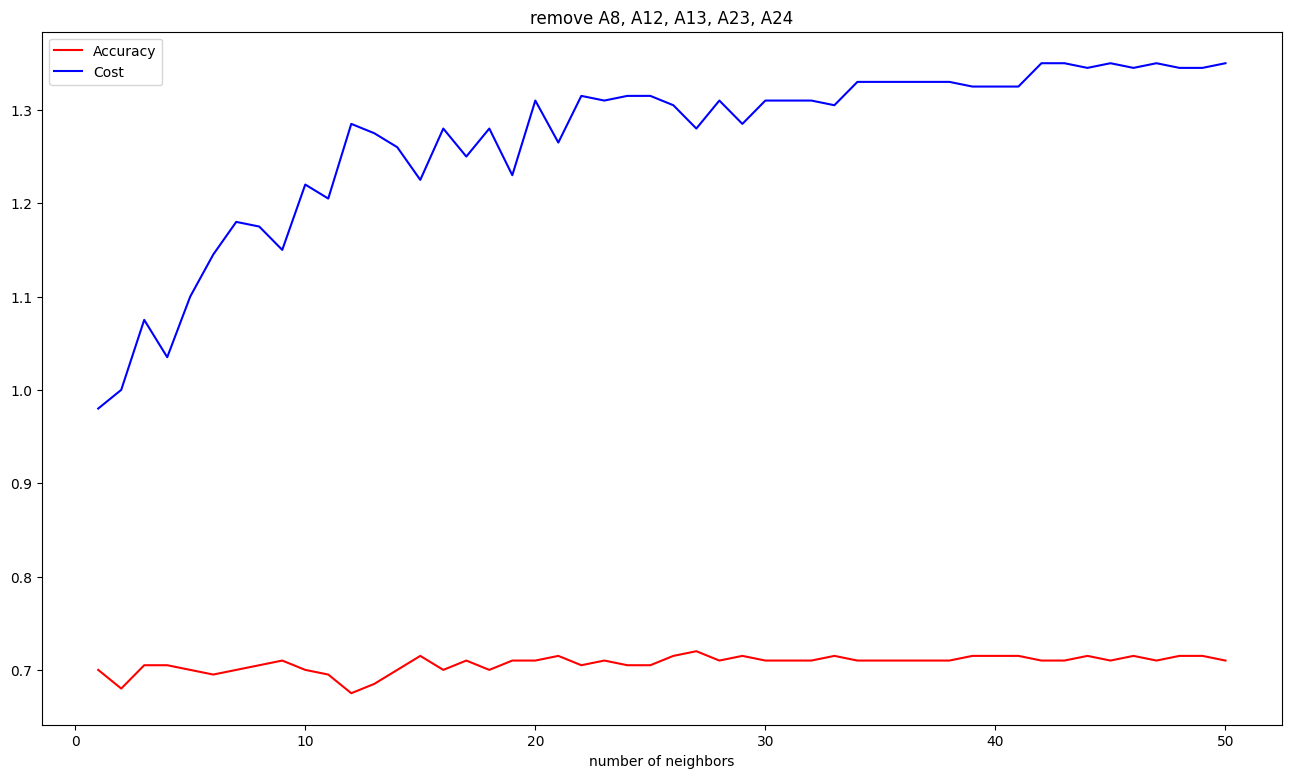

In [69]:
neighbors = [i for i in range(1,51)]
acc_score = []
cost_val = []
for i in neighbors:
    model = KNeighborsClassifier(n_neighbors = i, metric = 'euclidean', weights = 'distance')
    model.fit(X_train_lg, y_train)
    acc_score.append(accuracy_score(y_test, model.predict(X_test_lg)))
    cost_val.append(cost(y_test, model.predict(X_test_lg)))

plt.figure(figsize = (16,9))
plt.title("remove A8, A12, A13, A23, A24")
plt.xlabel('number of neighbors')
plt.plot(neighbors, acc_score, color = 'r', label = 'Accuracy')
plt.plot(neighbors, cost_val, color = 'b', label = 'Cost')
plt.legend()

Độ chính xác thấp hơn và cost còn cao hơn cả khi chưa remove

In [54]:
# bỏ đi các cột theo quan sát ma trận tương quan
X_train_observe = X_train.drop(columns = remove_candidate_observe)
X_test_observe = X_test.drop(columns = remove_candidate_observe)
sc.fit(X_train_observe)
sc.transform(X_test_observe)
sc.transform(X_train_observe)

array([[ 1.12561560e+00,  6.25157517e-04,  4.19639708e-01, ...,
         6.54653671e-01, -1.60128154e-01,  2.10764724e+00],
       [ 1.12561560e+00,  5.84105506e-01,  1.34702028e+00, ...,
         6.54653671e-01, -1.60128154e-01, -4.74462701e-01],
       [ 1.12561560e+00, -4.99500856e-01, -5.07740863e-01, ...,
         6.54653671e-01, -1.60128154e-01, -4.74462701e-01],
       ...,
       [-1.26084857e+00, -2.49437849e-01,  1.34702028e+00, ...,
        -1.52752523e+00, -1.60128154e-01, -4.74462701e-01],
       [-1.26084857e+00, -7.49563862e-01, -5.07740863e-01, ...,
         6.54653671e-01, -1.60128154e-01, -4.74462701e-01],
       [ 1.12561560e+00,  1.25094019e+00,  4.19639708e-01, ...,
        -1.52752523e+00, -1.60128154e-01, -4.74462701e-01]],
      shape=(800, 21))

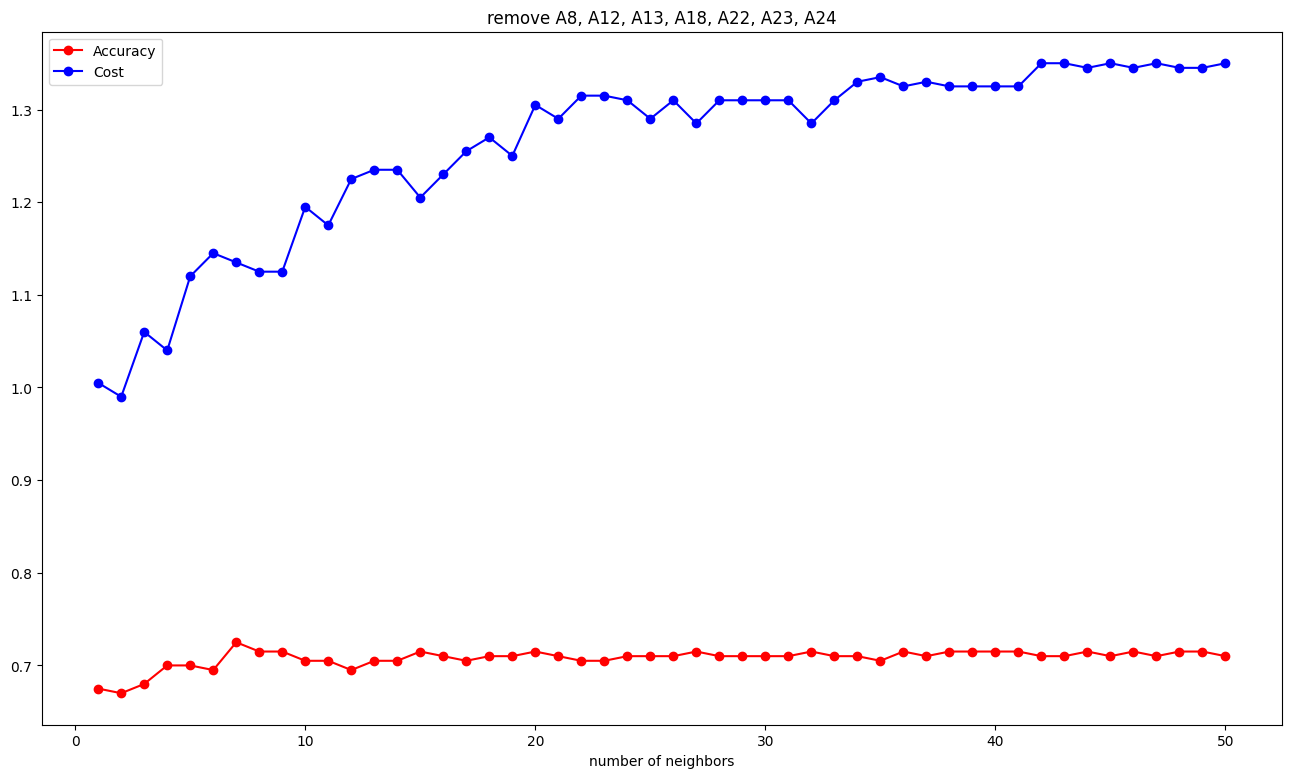

In [56]:
neighbors = [i for i in range(1,51)]
acc_score = []
cost_val = []
for i in neighbors:
    model = KNeighborsClassifier(n_neighbors = i, metric = 'minkowski', p =2, weights = 'distance')
    model.fit(X_train_observe, y_train)
    acc_score.append(accuracy_score(y_test, model.predict(X_test_observe)))
    cost_val.append(cost(y_test, model.predict(X_test_observe)))

plt.figure(figsize = (16,9))
plt.title("remove A8, A12, A13, A18, A22, A23, A24")
plt.xlabel('number of neighbors')
plt.plot(neighbors, acc_score, marker = 'o', color = 'r', label = 'Accuracy')
plt.plot(neighbors, cost_val, marker='o', color = 'b', label = 'Cost')
plt.legend()

Tệ hơn khi chưa remove ở 1 số số lượng láng giềng nhưng nói chung là tổng quát hơn và có vẻ là ít bị ảnh hưởng bởi nhiễu hơn, số lượng láng giềng lý tưởng là tầm 5 đến 10

In [62]:
# lựa chọn hàm tính khoảng cách, sử dụng tập train và test của observe
k = [i for i in range(1,101)]
distance_func = ['manhattan', 'euclidean', 'chebyshev']
acc = []
cost_m = []

for dis_func in distance_func:
    tmp_acc = []
    tmp_cost = []
    for j in k:
        model = KNeighborsClassifier(n_neighbors = j, metric = dis_func, weights = 'distance')
        model.fit(X_train_observe, y_train)
        y_pred = model.predict(X_test_observe)
        tmp_acc.append(accuracy_score(y_test, y_pred))
        tmp_cost.append(cost(y_test, y_pred))
    acc.append(tmp_acc)
    cost_m.append(tmp_cost)

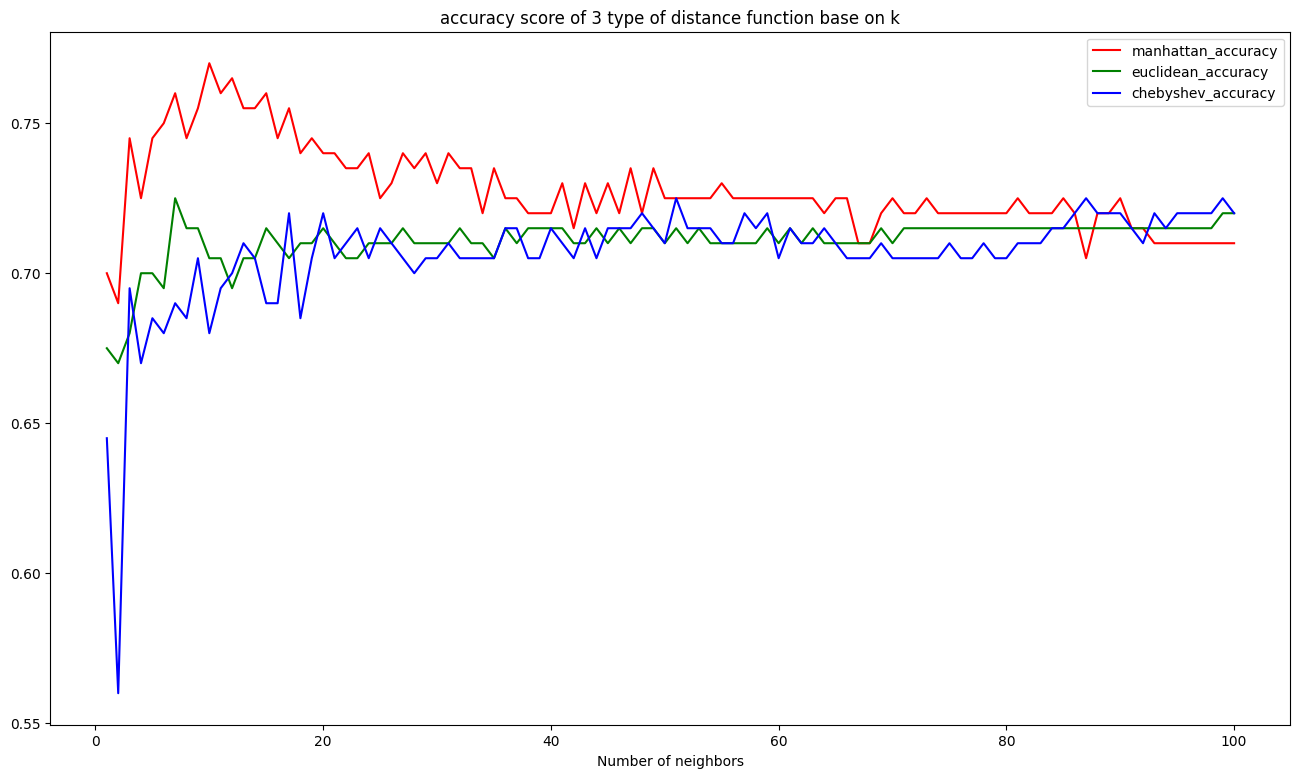

In [66]:
plt.figure(figsize = (16,9))
plt.title('accuracy score of 3 type of distance function base on k')
plt.xlabel('Number of neighbors')
plt.plot(k, acc[0], color = 'r', label = 'manhattan_accuracy')
plt.plot(k, acc[1], color = 'g', label = 'euclidean_accuracy')
plt.plot(k, acc[2], color = 'b', label = 'chebyshev_accuracy')
plt.legend()

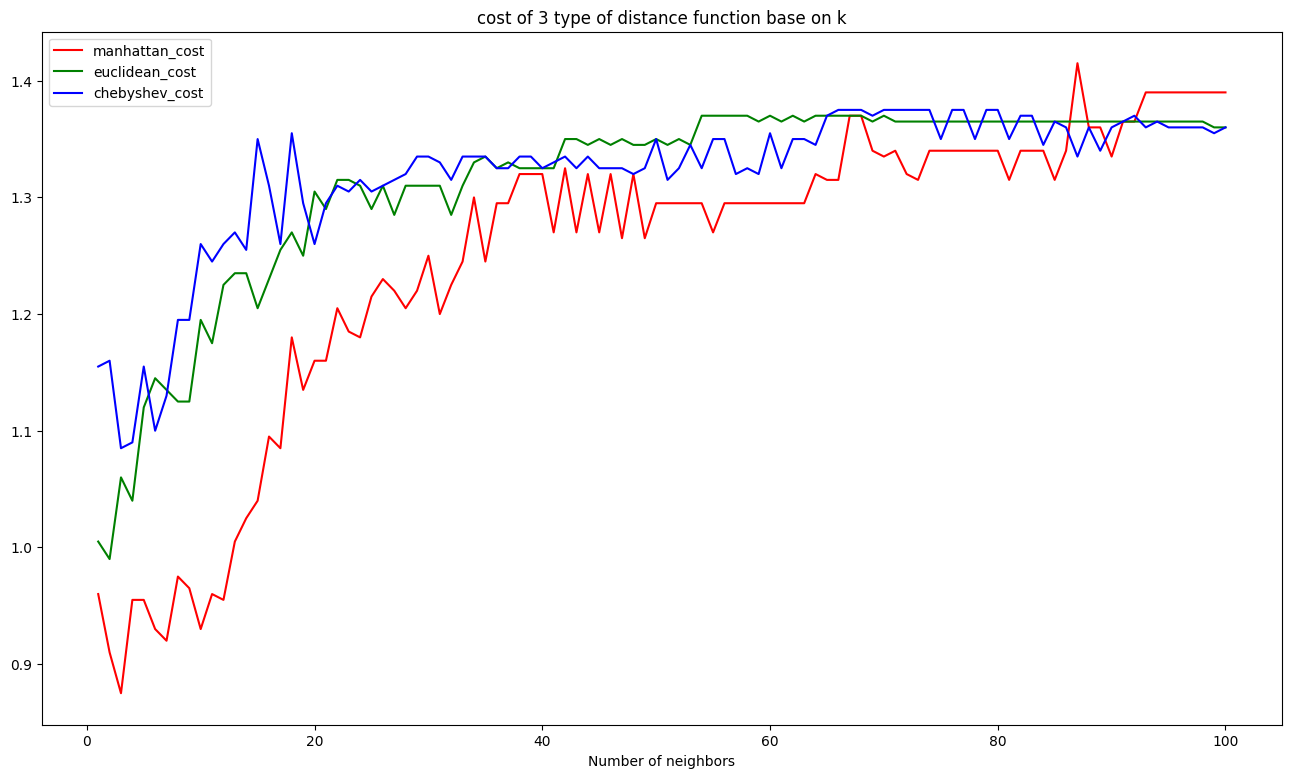

In [67]:
plt.figure(figsize = (16,9))
plt.title('cost of 3 type of distance function base on k')
plt.xlabel('Number of neighbors')
plt.plot(k, cost_m[0], color = 'r', label = 'manhattan_cost')
plt.plot(k, cost_m[1], color = 'g', label = 'euclidean_cost')
plt.plot(k, cost_m[2], color = 'b', label = 'chebyshev_cost')
plt.legend()

Trong bài toán này t thấy manhattan là tốt nhất khi cost thấp nhất trong 3 hàm và độ chính xác là cao nhất trong 3 hàm